# S4 — True Null Calibration + Variance-Only Detection: All Metrics

This notebook validates **all 43 metrics** on two categories of null-like data:

1. **True Null** (`spread = constant`): Y completely independent of X → FPR validation (should ≈ 5%)
2. **Variance-only** (`spread ≠ constant`): E[Y|X] = 0 but Var[Y|X] depends on X → detection power analysis

| Category | noise_dist | spread_pattern | x_dist | Per combo | Total |
|----------|-----------|----------------|--------|-----------|-------|
| True Null | 4 | constant (1) | 8 | 125 | **4,000** |
| Variance-only | 4 | increasing/decreasing/middle_high (3) | 8 | 30 | **2,880** |
| **Total** | | | | | **6,880** |

| Phase | Metrics | Est. time |
|-------|---------|----------|
| 1 | 4 core (|r|, |ρ|, η², dcor) | ~45 min |
| 2 | 30 vectorisable (slopes, bins, covariance...) | ~10 min |
| 3 | dcov | ~45 min |
| 4 | 4 distribution (KS, Wasserstein) | ~50 min |
| 5 | 4 MINE (MIC, MAS, MEV, MCN) | ~10 h |

**Environment:** pip39 (for MINE phase; other phases work in any env)

In [7]:
# ============================================================
# CONFIG
# ============================================================

RUN_MINE = True     # Phase 5: MINE metrics (~10 h)
N_PER_COMBO_NULL = 125   # True Null (constant spread): more cases for precise FPR
N_PER_COMBO_VAR  = 30    # Variance-only (non-constant spread)
N_PERM = 500
N_POINTS = 500
SEED_BASE = 99_000_000

NOISE_DISTRIBUTIONS = ['normal', 'uniform', 'heavy_tail', 'skewed']
SPREAD_PATTERNS_NULL = ['constant']
SPREAD_PATTERNS_VAR  = ['increasing', 'decreasing', 'middle_high']
SPREAD_PATTERNS = SPREAD_PATTERNS_NULL + SPREAD_PATTERNS_VAR

n_null = len(NOISE_DISTRIBUTIONS) * len(SPREAD_PATTERNS_NULL) * 8 * N_PER_COMBO_NULL
n_var  = len(NOISE_DISTRIBUTIONS) * len(SPREAD_PATTERNS_VAR)  * 8 * N_PER_COMBO_VAR
print(f'True Null:      4 noise × 1 spread × 8 x_dist × {N_PER_COMBO_NULL}/combo = {n_null}')
print(f'Variance-only:  4 noise × 3 spread × 8 x_dist × {N_PER_COMBO_VAR}/combo = {n_var}')
print(f'Total: {n_null + n_var}')
print(f'RUN_MINE: {RUN_MINE}')

True Null:      4 noise × 1 spread × 8 x_dist × 125/combo = 4000
Variance-only:  4 noise × 3 spread × 8 x_dist × 30/combo = 2880
Total: 6880
RUN_MINE: True


In [8]:
from __future__ import annotations

import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist, squareform
from scipy.stats import rankdata, ks_2samp, wasserstein_distance

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(it, **kw):
        return it

if RUN_MINE:
    from minepy import MINE

warnings.filterwarnings('ignore')

DATA_DIR = Path('generated_scatterplot_data')
OUT_DIR  = DATA_DIR / 'full' / 'S4_null_validate_all'
OUT_DIR.mkdir(parents=True, exist_ok=True)

X_DISTRIBUTIONS = ['even', 'left_dense', 'right_dense', 'center_dense',
                   'clusters_2', 'clusters_3', 'clusters_4', 'clusters_5']

print(f'Output → {OUT_DIR}')

Output → generated_scatterplot_data/full/S4_null_validate_all


## 1. Generate Null Data

Two categories with different sample sizes:
- **True Null** (constant spread, 125/combo): Y independent of X → for FPR validation
- **Variance-only** (non-constant spread, 30/combo): Var[Y|X] depends on X → for detection power

In [9]:
CLUSTER_OCCUPANCY = 0.4
CLUSTER_BACKGROUND_FRAC = 0.1


def _cluster_bounds(n_clusters):
    cluster_width = CLUSTER_OCCUPANCY / n_clusters
    gap_width = (1.0 - CLUSTER_OCCUPANCY) / (n_clusters + 1)
    bounds = []
    for i in range(n_clusters):
        lo = gap_width * (i + 1) + cluster_width * i
        hi = lo + cluster_width
        bounds.append((lo, hi))
    return bounds


def sample_x(n, distribution, rng):
    if distribution == 'even':
        return rng.uniform(0.0, 1.0, size=n)
    if distribution == 'left_dense':
        return rng.beta(2.0, 5.0, size=n)
    if distribution == 'right_dense':
        return rng.beta(5.0, 2.0, size=n)
    if distribution == 'center_dense':
        return rng.beta(5.0, 5.0, size=n)
    if distribution.startswith('clusters_'):
        n_clusters = int(distribution.split('_')[1])
        bounds = _cluster_bounds(n_clusters)
        is_bg = rng.random(size=n) < CLUSTER_BACKGROUND_FRAC
        n_bg = is_bg.sum()
        component = rng.integers(0, n_clusters, size=n)
        x = np.empty(n, dtype=float)
        for i, (lo, hi) in enumerate(bounds):
            mask = (~is_bg) & (component == i)
            x[mask] = rng.uniform(lo, hi, size=mask.sum())
        x[is_bg] = rng.uniform(0.0, 1.0, size=n_bg)
        return x
    raise ValueError(f'Unknown x distribution: {distribution}')


def spread_multiplier(x, pattern):
    """Same as S1: σ(x) = base_noise × spread(x)."""
    x = np.asarray(x, dtype=float)
    if pattern == 'constant':
        return np.ones_like(x)
    if pattern == 'increasing':
        return 0.2 + 1.6 * x
    if pattern == 'decreasing':
        return 1.8 - 1.6 * x
    if pattern == 'middle_high':
        return 0.3 + 1.4 * np.exp(-((x - 0.5) ** 2) / 0.02)
    raise ValueError(f'Unknown spread pattern: {pattern}')


def generate_null_y(x, noise_dist, spread_pattern, rng):
    """Same as S1's Null generation: y = raw * σ(x), independent of x."""
    n = len(x)
    sigma_i = spread_multiplier(x, spread_pattern)
    if noise_dist == 'normal':
        raw = rng.normal(0.0, 1.0, size=n)
    elif noise_dist == 'uniform':
        raw = rng.uniform(-1.0, 1.0, size=n) * np.sqrt(3.0)
    elif noise_dist == 'heavy_tail':
        raw = rng.standard_t(df=3, size=n) / np.sqrt(3.0)
    elif noise_dist == 'skewed':
        raw = rng.exponential(1.0, size=n) - 1.0
    else:
        raise ValueError(f'Unknown noise distribution: {noise_dist}')
    return raw * sigma_i


print('Samplers ready')

Samplers ready


In [10]:
n_total = n_null + n_var
x_all = np.empty((n_total, N_POINTS), dtype=np.float64)
y_all = np.empty((n_total, N_POINTS), dtype=np.float64)
meta_rows = []

idx = 0
for xd in X_DISTRIBUTIONS:
    for nd in NOISE_DISTRIBUTIONS:
        for sp in SPREAD_PATTERNS:
            n_per = N_PER_COMBO_NULL if sp == 'constant' else N_PER_COMBO_VAR
            for k in range(n_per):
                seed = SEED_BASE + idx
                rng = np.random.default_rng(seed)
                x = sample_x(N_POINTS, xd, rng)
                y = generate_null_y(x, nd, sp, rng)
                x_all[idx] = x
                y_all[idx] = y
                category = 'true_null' if sp == 'constant' else 'variance_only'
                meta_rows.append({
                    'null_id': idx, 'x_distribution': xd,
                    'noise_dist': nd, 'spread_pattern': sp,
                    'category': category, 'seed': seed,
                })
                idx += 1

assert idx == n_total, f'Expected {n_total}, got {idx}'
meta_df = pd.DataFrame(meta_rows)

is_null = meta_df['category'] == 'true_null'
is_var  = meta_df['category'] == 'variance_only'

print(f'Generated {n_total} cases:')
print(f'  True Null:      {is_null.sum()} (spread=constant, {N_PER_COMBO_NULL}/combo)')
print(f'  Variance-only:  {is_var.sum()} (spread≠constant, {N_PER_COMBO_VAR}/combo)')
print()
print(meta_df.groupby(['category', 'noise_dist']).size().unstack(fill_value=0).to_string())

Generated 6880 cases:
  True Null:      4000 (spread=constant, 125/combo)
  Variance-only:  2880 (spread≠constant, 30/combo)

noise_dist     heavy_tail  normal  skewed  uniform
category                                          
true_null            1000    1000    1000     1000
variance_only         720     720     720      720


In [11]:
def _generate_perms(n, n_perm, seed):
    rng = np.random.default_rng(seed)
    return np.array([rng.permutation(n) for _ in range(n_perm)])


def _z_and_p(obs, null, direction=1):
    """Z-score + p-value. direction=1: higher=signal, -1: lower=signal."""
    med = float(np.median(null))
    iqr = float(np.percentile(null, 75) - np.percentile(null, 25))
    if iqr < 1e-12:
        iqr = float(np.std(null)) * 1.35
    if iqr < 1e-12:
        return 0.0, np.zeros(len(null)), med, iqr, 1.0
    z_obs = direction * (obs - med) / iqr
    z_null = direction * (null - med) / iqr
    p = float(np.sum(z_null >= z_obs) + 1) / (len(null) + 1)
    return z_obs, z_null, med, iqr, p


def _double_center(a):
    D = squareform(pdist(a.reshape(-1, 1)))
    return D - D.mean(axis=0, keepdims=True) - D.mean(axis=1, keepdims=True) + D.mean()


def _precompute_bins(x, n_bins=10, min_count=5, bin_type='equal_width'):
    if bin_type == 'equal_width':
        try:
            bins = np.asarray(
                pd.cut(x, bins=n_bins, labels=False, include_lowest=True, duplicates='drop'),
                dtype=float)
        except Exception:
            return None
    else:
        try:
            bins = np.asarray(
                pd.qcut(x, q=n_bins, labels=False, duplicates='drop'),
                dtype=float)
        except Exception:
            return None
    valid_ids = np.unique(bins[~np.isnan(bins)]).astype(int)
    masks, counts = [], []
    for b in valid_ids:
        m = bins == b
        if m.sum() >= min_count:
            masks.append(m)
            counts.append(m.sum())
    if len(masks) < 2:
        return None
    B_ind = np.array([m.astype(np.float64) for m in masks])
    return B_ind, np.array(counts, dtype=np.float64)


LOWER_IS_SIGNAL = {
    'ew_bin_bw_mean', 'ew_bin_bw_early', 'ew_bin_bw_mid', 'ew_bin_bw_late',
    'ec_bin_bw_mean', 'ec_bin_bw_early', 'ec_bin_bw_mid', 'ec_bin_bw_late',
}

print('Helpers ready')

Helpers ready


## Phase 1 — Core 4 Metrics (|r|, |ρ|, η², dcor)

|r|, |ρ|, η² are vectorised; dcor requires a per-permutation loop.

In [12]:
core_obs = {m: np.empty(n_total) for m in ['pearson', 'spearman', 'eta2', 'dcor']}
core_null = {m: np.empty((n_total, N_PERM), dtype=np.float32) for m in ['pearson', 'spearman', 'eta2', 'dcor']}

t0 = time.time()
for i in tqdm(range(n_total), desc='Phase 1'):
    x = x_all[i]; y = y_all[i]
    perms = _generate_perms(len(x), N_PERM, SEED_BASE + n_total + i)

    # |Pearson|
    xc = x - x.mean(); yc = y - y.mean()
    sx = np.sqrt((xc**2).sum()); sy = np.sqrt((yc**2).sum())
    if sx > 0 and sy > 0:
        d = sx * sy
        core_obs['pearson'][i] = abs(float((xc*yc).sum() / d))
        core_null['pearson'][i] = np.abs((xc * yc[perms]).sum(axis=1) / d)
    else:
        core_obs['pearson'][i] = 0.0; core_null['pearson'][i] = 0.0

    # |Spearman|
    xr = rankdata(x).astype(np.float64); yr = rankdata(y).astype(np.float64)
    xrc = xr - xr.mean(); yrc = yr - yr.mean()
    sxr = np.sqrt((xrc**2).sum()); syr = np.sqrt((yrc**2).sum())
    if sxr > 0 and syr > 0:
        dr = sxr * syr
        core_obs['spearman'][i] = abs(float((xrc*yrc).sum() / dr))
        core_null['spearman'][i] = np.abs((xrc * yrc[perms]).sum(axis=1) / dr)
    else:
        core_obs['spearman'][i] = 0.0; core_null['spearman'][i] = 0.0

    # η² (equal-width bins)
    bin_info = _precompute_bins(x, bin_type='equal_width')
    y_mean = float(y.mean()); ss_total = float(((y - y_mean)**2).sum())
    if bin_info is not None and ss_total > 0:
        B_ind, bin_counts = bin_info
        bm_obs = (B_ind @ y) / bin_counts
        core_obs['eta2'][i] = float((bin_counts * (bm_obs - y_mean)**2).sum() / ss_total)
        y_perms = y[perms]
        bm_null = (y_perms @ B_ind.T) / bin_counts
        core_null['eta2'][i] = ((bin_counts * (bm_null - y_mean)**2).sum(axis=1) / ss_total).astype(np.float32)
    else:
        core_obs['eta2'][i] = 0.0; core_null['eta2'][i] = 0.0

    # dcor
    A = _double_center(x); B = _double_center(y)
    dcov_xx = np.sqrt(max((A*A).mean(), 0))
    dcov_yy = np.sqrt(max((B*B).mean(), 0))
    dcov_denom = np.sqrt(dcov_xx * dcov_yy)
    dcov_obs_val = np.sqrt(max(float((A*B).mean()), 0))
    core_obs['dcor'][i] = float(dcov_obs_val / dcov_denom) if dcov_denom > 0 else 0.0
    if dcov_denom > 0:
        for k in range(N_PERM):
            p = perms[k]
            dcov2 = float((A * B[p][:, p]).mean())
            core_null['dcor'][i, k] = np.sqrt(max(dcov2, 0)) / dcov_denom
    else:
        core_null['dcor'][i] = 0.0

elapsed = (time.time()-t0)/60
print(f'Phase 1 done in {elapsed:.1f} min')

# Checkpoint
np.savez_compressed(
    OUT_DIR / '_phase1_core.npz',
    **{f'{m}_obs': core_obs[m] for m in core_obs},
    **{f'{m}_null': core_null[m] for m in core_null},
)
print(f'Checkpoint saved: _phase1_core.npz')

Phase 1: 100%|██████████| 6880/6880 [1:09:54<00:00,  1.64it/s]


Phase 1 done in 69.9 min
Checkpoint saved: _phase1_core.npz


## Phase 2 — Vectorisable Extended Metrics (30 metrics)

Same computation as S3_permutation_test_all_metrics Phase 1:
covariance, raw/std endpoint slopes, raw/std polyfit slopes (4 segments each),
segment strength, equal-width/equal-count bin amplitude, buffer widths, ec_bin_eta2.

In [13]:
def compute_extended_case(x, y, perms):
    """All vectorisable extended metrics for one case."""
    n = len(x)
    n_perm = len(perms)
    R = {}
    y_perms = y[perms]

    # Covariance
    xc = x - x.mean(); yc = y - y.mean()
    R['abs_covariance'] = (abs(float((xc*yc).sum()/(n-1))),
                           np.abs((xc*yc[perms]).sum(1)/(n-1)))

    # Slopes (raw + standardized)
    sort_idx = np.argsort(x)
    n1, n2 = n//3, 2*n//3
    seg_slices = {'overall': slice(None), 'early': slice(None,n1),
                  'mid': slice(n1,n2), 'late': slice(n2,None)}

    for pfx, sxs, syo, syp in [
        ('raw', x[sort_idx], y[sort_idx], y_perms[:, sort_idx]),
        ('std', None, None, None),
    ]:
        if pfx == 'std':
            xlo, xhi = x.min(), x.max()
            xn = (x-xlo)/(xhi-xlo) if xhi>xlo else np.full(n, 0.5)
            sxs = xn[sort_idx]
            ylo_p = y_perms.min(1, keepdims=True)
            yhi_p = y_perms.max(1, keepdims=True)
            yr_p = yhi_p - ylo_p
            syp = np.where(yr_p>0, (y_perms-ylo_p)/yr_p, 0.5)[:, sort_idx]
            ylo_o, yhi_o = y.min(), y.max()
            syo = ((y-ylo_o)/(yhi_o-ylo_o) if yhi_o>ylo_o else np.full(n,0.5))[sort_idx]

        ep_seg_obs, ep_seg_null = [], []
        for sname, slc in seg_slices.items():
            seg_x = sxs[slc]; seg_yo = syo[slc]; seg_yp = syp[:, slc]
            if len(seg_x) < 2:
                R[f'abs_{pfx}_ep_{sname}'] = (0., np.zeros(n_perm))
                R[f'abs_{pfx}_pf_{sname}'] = (0., np.zeros(n_perm))
                continue
            dx = seg_x[-1] - seg_x[0]
            if abs(dx) > 0:
                ep_o = abs(float((seg_yo[-1]-seg_yo[0])/dx))
                ep_n = np.abs((seg_yp[:,-1]-seg_yp[:,0])/dx)
            else:
                ep_o = 0.; ep_n = np.zeros(n_perm)
            R[f'abs_{pfx}_ep_{sname}'] = (ep_o, ep_n)
            seg_xc = seg_x - seg_x.mean()
            denom_pf = (seg_xc**2).sum()
            if denom_pf > 0 and len(seg_x) >= 3:
                pf_o = abs(float((seg_xc*(seg_yo-seg_yo.mean())).sum()/denom_pf))
                pf_n = np.abs((seg_xc*(seg_yp-seg_yp.mean(1,keepdims=True))).sum(1)/denom_pf)
            else:
                pf_o = 0.; pf_n = np.zeros(n_perm)
            R[f'abs_{pfx}_pf_{sname}'] = (pf_o, pf_n)
            if sname != 'overall':
                ep_seg_obs.append(ep_o); ep_seg_null.append(ep_n)
        if ep_seg_null:
            R[f'{pfx}_seg_strength'] = (float(np.mean(ep_seg_obs)),
                                        np.mean(ep_seg_null, axis=0))

    # Bin metrics (equal-width + equal-count)
    for bt, abbr in [('equal_width','ew'), ('equal_count','ec')]:
        bi = _precompute_bins(x, bin_type=bt)
        y_mean = float(y.mean()); ss_tot = float(((y-y_mean)**2).sum())
        fallback_names = [f'{abbr}_bin_amp',
                          f'{abbr}_bin_bw_mean', f'{abbr}_bin_bw_early',
                          f'{abbr}_bin_bw_mid', f'{abbr}_bin_bw_late']
        if abbr == 'ec':
            fallback_names.insert(0, f'{abbr}_bin_eta2')
        if bi is None or ss_tot <= 0:
            for nm in fallback_names:
                R[nm] = (0., np.zeros(n_perm))
            continue
        B_ind, bcounts = bi
        nb = len(bcounts)
        bm_obs = (B_ind @ y) / bcounts
        bm_null = (y_perms @ B_ind.T) / bcounts
        if abbr == 'ec':
            R[f'{abbr}_bin_eta2'] = (
                float((bcounts*(bm_obs-y_mean)**2).sum()/ss_tot),
                (bcounts*(bm_null-y_mean)**2).sum(1)/ss_tot)
        R[f'{abbr}_bin_amp'] = (
            float(bm_obs.max()-bm_obs.min()),
            bm_null.max(1)-bm_null.min(1))
        masks_bool = [B_ind[b].astype(bool) for b in range(nb)]
        bw_obs_arr = np.empty(nb); bw_null_arr = np.empty((n_perm, nb))
        for b in range(nb):
            m = masks_bool[b]
            yb_o = y[m]
            bw_obs_arr[b] = np.percentile(yb_o,95) - np.percentile(yb_o,5)
            yb_n = y_perms[:, m]
            bw_null_arr[:,b] = np.percentile(yb_n,95,axis=1) - np.percentile(yb_n,5,axis=1)
        R[f'{abbr}_bin_bw_mean'] = (float(bw_obs_arr.mean()), bw_null_arr.mean(1))
        i1b, i2b = nb//3, 2*nb//3
        for nm, slc in [(f'{abbr}_bin_bw_early', slice(None,max(i1b,1))),
                        (f'{abbr}_bin_bw_mid', slice(max(i1b,1),max(i2b,i1b+1))),
                        (f'{abbr}_bin_bw_late', slice(max(i2b,i1b+1),None))]:
            o = float(bw_obs_arr[slc].mean()) if len(bw_obs_arr[slc]) else 0.
            n_ = bw_null_arr[:,slc].mean(1) if bw_null_arr[:,slc].shape[1]>0 else np.zeros(n_perm)
            R[nm] = (o, n_)
    return R


# Run Phase 2
EXT_METRICS = None
ext_results = []

t0 = time.time()
for i in tqdm(range(n_total), desc='Phase 2 (extended)'):
    x = x_all[i].astype(np.float64); y = y_all[i].astype(np.float64)
    perms = _generate_perms(len(x), N_PERM, SEED_BASE + n_total + i)
    R = compute_extended_case(x, y, perms)
    if EXT_METRICS is None:
        EXT_METRICS = sorted(R.keys())
    row = {}
    for nm in EXT_METRICS:
        obs_val, null_arr = R[nm]
        d = -1 if nm in LOWER_IS_SIGNAL else 1
        z_o, z_n, med, iqr, p = _z_and_p(obs_val, null_arr.astype(np.float64), d)
        row[f'{nm}_obs'] = obs_val
        row[f'z_{nm}'] = z_o
        row[f'p_{nm}'] = p
    ext_results.append(row)

print(f'Phase 2 done in {(time.time()-t0)/60:.1f} min')
print(f'Extended metrics ({len(EXT_METRICS)}): {EXT_METRICS}')

# Checkpoint
ext_df = pd.DataFrame(ext_results)
ext_df.to_parquet(OUT_DIR / '_phase2_extended.parquet', index=False)
print(f'Checkpoint saved: _phase2_extended.parquet')

Phase 2 (extended): 100%|██████████| 6880/6880 [12:28<00:00,  9.19it/s]


Phase 2 done in 12.5 min
Extended metrics (30): ['abs_covariance', 'abs_raw_ep_early', 'abs_raw_ep_late', 'abs_raw_ep_mid', 'abs_raw_ep_overall', 'abs_raw_pf_early', 'abs_raw_pf_late', 'abs_raw_pf_mid', 'abs_raw_pf_overall', 'abs_std_ep_early', 'abs_std_ep_late', 'abs_std_ep_mid', 'abs_std_ep_overall', 'abs_std_pf_early', 'abs_std_pf_late', 'abs_std_pf_mid', 'abs_std_pf_overall', 'ec_bin_amp', 'ec_bin_bw_early', 'ec_bin_bw_late', 'ec_bin_bw_mean', 'ec_bin_bw_mid', 'ec_bin_eta2', 'ew_bin_amp', 'ew_bin_bw_early', 'ew_bin_bw_late', 'ew_bin_bw_mean', 'ew_bin_bw_mid', 'raw_seg_strength', 'std_seg_strength']
Checkpoint saved: _phase2_extended.parquet


## Phase 3 — Distance Covariance (dcov)

In [14]:
dcov_obs = np.empty(n_total)
dcov_null = np.empty((n_total, N_PERM), dtype=np.float32)

t0 = time.time()
for i in tqdm(range(n_total), desc='Phase 3 (dcov)'):
    x = x_all[i]; y = y_all[i]
    perms = _generate_perms(len(x), N_PERM, SEED_BASE + n_total + i)
    A = _double_center(x); B = _double_center(y)
    dcov_obs[i] = np.sqrt(max(float((A*B).mean()), 0))
    for k in range(N_PERM):
        p = perms[k]
        v = float((A * B[p][:, p]).mean())
        dcov_null[i, k] = np.sqrt(max(v, 0))

print(f'Phase 3 done in {(time.time()-t0)/60:.1f} min')

# Checkpoint
np.savez_compressed(
    OUT_DIR / '_phase3_dcov.npz',
    dcov_obs=dcov_obs, dcov_null=dcov_null,
)
print(f'Checkpoint saved: _phase3_dcov.npz')

Phase 3 (dcov): 100%|██████████| 6880/6880 [50:36<00:00,  2.27it/s] 


Phase 3 done in 50.6 min
Checkpoint saved: _phase3_dcov.npz


## Phase 4 — Distribution Metrics (KS, Wasserstein)

In [15]:
dist_results = []

t0 = time.time()
for i in tqdm(range(n_total), desc='Phase 4 (dist)'):
    x = x_all[i].astype(np.float64); y = y_all[i].astype(np.float64)
    perms = _generate_perms(len(x), N_PERM, SEED_BASE + n_total + i)
    y_perms = y[perms]
    row = {}

    for bt, abbr in [('equal_width','ew'), ('equal_count','ec')]:
        bi = _precompute_bins(x, bin_type=bt)
        if bi is None or len(bi[1]) < 3:
            for nm in [f'{abbr}_dist_ks', f'{abbr}_dist_wass']:
                row[f'{nm}_obs'] = 0.; row[f'z_{nm}'] = 0.; row[f'p_{nm}'] = 1.
            continue
        B_ind, bcounts = bi
        nv = len(bcounts)
        low_mask = B_ind[:max(nv//3,1)].max(0).astype(bool)
        high_mask = B_ind[max(2*nv//3, nv//3+1):].max(0).astype(bool)
        y_lo_o, y_hi_o = y[low_mask], y[high_mask]
        if len(y_lo_o) < 2 or len(y_hi_o) < 2:
            for nm in [f'{abbr}_dist_ks', f'{abbr}_dist_wass']:
                row[f'{nm}_obs'] = 0.; row[f'z_{nm}'] = 0.; row[f'p_{nm}'] = 1.
            continue
        ks_obs = float(ks_2samp(y_lo_o, y_hi_o).statistic)
        w_obs = float(wasserstein_distance(y_lo_o, y_hi_o))
        ks_null = np.empty(N_PERM); w_null = np.empty(N_PERM)
        for k in range(N_PERM):
            yl = y_perms[k, low_mask]; yh = y_perms[k, high_mask]
            ks_null[k] = ks_2samp(yl, yh).statistic
            w_null[k] = wasserstein_distance(yl, yh)
        for nm, obs, null in [(f'{abbr}_dist_ks', ks_obs, ks_null),
                               (f'{abbr}_dist_wass', w_obs, w_null)]:
            z_o, _, _, _, pv = _z_and_p(obs, null, 1)
            row[f'{nm}_obs'] = obs; row[f'z_{nm}'] = z_o; row[f'p_{nm}'] = pv
    dist_results.append(row)

print(f'Phase 4 done in {(time.time()-t0)/60:.1f} min')

# Checkpoint
dist_df = pd.DataFrame(dist_results)
dist_df.to_parquet(OUT_DIR / '_phase4_dist.parquet', index=False)
print(f'Checkpoint saved: _phase4_dist.parquet')

Phase 4 (dist): 100%|██████████| 6880/6880 [32:51<00:00,  3.49it/s]

Phase 4 done in 32.9 min
Checkpoint saved: _phase4_dist.parquet


## Phase 5 — MINE Metrics (MIC, MAS, MEV, MCN)

Requires `minepy`. Set `RUN_MINE = False` in CONFIG to skip.

In [16]:
mine_names = ['MIC', 'MAS', 'MEV', 'MCN']
mine_obs = {m: np.empty(n_total) for m in mine_names}
mine_null = {m: np.empty((n_total, N_PERM), dtype=np.float32) for m in mine_names}

if RUN_MINE:
    def compute_mine(x, y):
        m = MINE()
        m.compute_score(x, y)
        return m.mic(), m.mas(), m.mev(), m.mcn()

    # --- Resume from checkpoint ---
    start_i = 0
    ckpt_files = sorted(OUT_DIR.glob('_mine_ckpt_*.npz'))
    if ckpt_files:
        latest = ckpt_files[-1]
        ckpt = np.load(latest)
        done = int(ckpt['completed'])
        for m in mine_names:
            mine_obs[m][:done] = ckpt[f'{m}_obs']
            mine_null[m][:done] = ckpt[f'{m}_null']
        start_i = done
        print(f'Resuming from checkpoint: {latest.name} ({done} cases done)')
    else:
        print('No checkpoint found, starting from 0')

    t0 = time.time()
    for i in tqdm(range(start_i, n_total), desc='Phase 5 (MINE)',
                  initial=start_i, total=n_total):
        x = x_all[i]; y = y_all[i]
        perms = _generate_perms(len(x), N_PERM, SEED_BASE + 2*n_total + i)

        mic, mas, mev, mcn = compute_mine(x, y)
        mine_obs['MIC'][i] = mic; mine_obs['MAS'][i] = mas
        mine_obs['MEV'][i] = mev; mine_obs['MCN'][i] = mcn

        for k in range(N_PERM):
            mic_k, mas_k, mev_k, mcn_k = compute_mine(x, y[perms[k]])
            mine_null['MIC'][i, k] = mic_k; mine_null['MAS'][i, k] = mas_k
            mine_null['MEV'][i, k] = mev_k; mine_null['MCN'][i, k] = mcn_k

        if (i + 1) % 500 == 0:
            elapsed = time.time() - t0
            done_this_run = i + 1 - start_i
            rate = done_this_run / elapsed
            eta_h = (n_total - i - 1) / rate / 3600
            print(f'  [{i+1:>5,}/{n_total:,}]  {rate:.2f} cases/s  ETA {eta_h:.1f} h')
            np.savez_compressed(
                OUT_DIR / f'_mine_ckpt_{i+1:06d}.npz',
                completed=i+1,
                **{f'{m}_obs': mine_obs[m][:i+1] for m in mine_names},
                **{f'{m}_null': mine_null[m][:i+1] for m in mine_names},
            )

    total_elapsed = time.time() - t0
    done_this_run = n_total - start_i
    if start_i > 0:
        print(f'Phase 5 done: {done_this_run} new cases in {total_elapsed/3600:.1f} h '
              f'(resumed from {start_i})')
    else:
        print(f'Phase 5 done in {total_elapsed/3600:.1f} hours')
else:
    for m in mine_names:
        mine_obs[m][:] = np.nan; mine_null[m][:] = np.nan
    print('Phase 5 skipped (RUN_MINE = False)')

No checkpoint found, starting from 0


Phase 5 (MINE):   7%|▋         | 500/6880 [1:07:19<10:21:32,  5.85s/it]  

  [  500/6,880]  0.12 cases/s  ETA 14.3 h


Phase 5 (MINE):  15%|█▍        | 999/6880 [1:54:16<9:16:36,  5.68s/it] 

  [1,000/6,880]  0.15 cases/s  ETA 11.2 h


...

  [6,000/6,880]  0.13 cases/s  ETA 1.8 h


Phase 5 (MINE):  94%|█████████▍| 6499/6880 [13:41:28<3:55:11, 37.04s/it]  

  [6,500/6,880]  0.13 cases/s  ETA 0.8 h


Phase 5 (MINE): 100%|██████████| 6880/6880 [14:16:45<00:00,  7.47s/it]  

Phase 5 done in 14.3 hours


In [21]:

# ── Phase 6: LOWESS R² ──────────────────────────────────────
from statsmodels.nonparametric.smoothers_lowess import lowess
RUN_LOWESS_R2 = True          # ← 改 False 可跳过
LOWESS_FRAC = 0.3
LOWESS_IT   = 3
LOWESS_SEED_OFFSET = 3        # seed = SEED_BASE + 3*n_total + i

r2_obs  = np.empty(n_total)
r2_null = np.empty((n_total, N_PERM), dtype=np.float32)


def lowess_r2(x, y):
    if len(x) < 5:
        return 0.0
    order = np.argsort(x)
    xs, ys = x[order], y[order]
    fitted = lowess(ys, xs, frac=LOWESS_FRAC, it=LOWESS_IT, return_sorted=True)
    yp = np.interp(xs, fitted[:, 0], fitted[:, 1])
    ss_res = float(((ys - yp) ** 2).sum())
    ss_tot = float(((ys - ys.mean()) ** 2).sum())
    return 1.0 - ss_res / ss_tot if ss_tot > 0 else 0.0


if RUN_LOWESS_R2:
    start_i = 0
    ckpt_files = sorted(OUT_DIR.glob('_r2_ckpt_*.npz'))
    if ckpt_files:
        latest = ckpt_files[-1]
        ckpt = np.load(latest)
        done = int(ckpt['completed'])
        r2_obs[:done]  = ckpt['r2_obs']
        r2_null[:done]  = ckpt['r2_null']
        start_i = done
        print(f'Resuming from checkpoint: {latest.name} ({done} cases done)')
    else:
        print('No checkpoint found, starting from 0')

    t0 = time.time()
    for i in tqdm(range(start_i, n_total), desc='Phase 6 (LOWESS R²)',
                  initial=start_i, total=n_total):
        x = x_all[i].astype(np.float64)
        y = y_all[i].astype(np.float64)
        perms = _generate_perms(len(x), N_PERM,
                                SEED_BASE + LOWESS_SEED_OFFSET * n_total + i)

        r2_obs[i] = lowess_r2(x, y)
        for k in range(N_PERM):
            r2_null[i, k] = lowess_r2(x, y[perms[k]])

        if (i + 1) % 500 == 0:
            elapsed = time.time() - t0
            done_this_run = i + 1 - start_i
            rate = done_this_run / elapsed
            eta_h = (n_total - i - 1) / rate / 3600
            print(f'  [{i+1:>5,}/{n_total:,}]  {rate:.2f} cases/s  ETA {eta_h:.1f} h')
            np.savez_compressed(
                OUT_DIR / f'_r2_ckpt_{i+1:06d}.npz',
                completed=i + 1,
                r2_obs=r2_obs[:i + 1],
                r2_null=r2_null[:i + 1],
            )

    total_elapsed = time.time() - t0
    done_this_run = n_total - start_i
    if start_i > 0:
        print(f'Phase 6 done: {done_this_run} new cases in {total_elapsed/3600:.1f} h '
              f'(resumed from {start_i})')
    else:
        print(f'Phase 6 done in {total_elapsed/3600:.1f} hours')
else:
    r2_obs[:]  = np.nan
    r2_null[:] = np.nan
    print('Phase 6 skipped (RUN_LOWESS_R2 = False)')

No checkpoint found, starting from 0


Phase 6 (LOWESS R²):   7%|▋         | 500/6880 [54:51<11:44:16,  6.62s/it]

  [  500/6,880]  0.15 cases/s  ETA 11.7 h


Phase 6 (LOWESS R²):  15%|█▍        | 1000/6880 [2:08:43<11:04:20,  6.78s/it]

  [1,000/6,880]  0.13 cases/s  ETA 12.6 h


...

  [6,000/6,880]  0.14 cases/s  ETA 1.8 h


Phase 6 (LOWESS R²):  94%|█████████▍| 6499/6880 [13:11:23<41:13,  6.49s/it]  

  [6,500/6,880]  0.14 cases/s  ETA 0.8 h


Phase 6 (LOWESS R²): 100%|██████████| 6880/6880 [13:53:05<00:00,  7.27s/it]

Phase 6 done in 13.9 hours


## 3. Analysis

**Part A — True Null FPR** (constant spread, n=4,000): validate that each metric's FP rate ≈ 5%.

**Part B — Variance-only detection** (non-constant spread, n=2,880): which metrics detect variance-only relationships?

In [17]:
import matplotlib.pyplot as plt
%matplotlib inline

z_val = 1.96

def wilson_ci(p_hat, n):
    d = 1 + z_val**2 / n
    c = (p_hat + z_val**2 / (2*n)) / d
    m = z_val * np.sqrt((p_hat*(1-p_hat) + z_val**2/(4*n)) / n) / d
    return c - m, c + m


# ── Compute per-case p-values for ALL cases ──
pval_all = meta_df[['null_id', 'x_distribution', 'noise_dist',
                     'spread_pattern', 'category']].copy()

# Core 4
for mname in ['pearson', 'spearman', 'dcor', 'eta2']:
    pval_all[f'p_{mname}'] = [
        (np.sum(core_null[mname][i].astype(np.float64) >= core_obs[mname][i]) + 1) / (N_PERM + 1)
        for i in range(n_total)
    ]

# Extended (30)
for nm in EXT_METRICS:
    pval_all[f'p_{nm}'] = ext_df[f'p_{nm}'].values

# dcov
pval_all['p_dcov'] = [
    (np.sum(dcov_null[i].astype(np.float64) >= dcov_obs[i]) + 1) / (N_PERM + 1)
    for i in range(n_total)
]

# Distribution (4)
for nm in ['ew_dist_ks', 'ew_dist_wass', 'ec_dist_ks', 'ec_dist_wass']:
    pval_all[f'p_{nm}'] = dist_df[f'p_{nm}'].values

# MINE (4)
if RUN_MINE:
    for mname in mine_names:
        pval_all[f'p_{mname}'] = [
            (np.sum(mine_null[mname][i].astype(np.float64) >= mine_obs[mname][i]) + 1) / (N_PERM + 1)
            for i in range(n_total)
        ]

all_metric_names = (['pearson', 'spearman', 'dcor', 'eta2'] +
                    EXT_METRICS + ['dcov'] +
                    ['ew_dist_ks', 'ew_dist_wass', 'ec_dist_ks', 'ec_dist_wass'])
if RUN_MINE:
    all_metric_names += mine_names

metric_group = {}
for m in ['pearson', 'spearman', 'dcor', 'eta2']:
    metric_group[m] = 'core'
for m in EXT_METRICS:
    metric_group[m] = 'extended'
metric_group['dcov'] = 'dcov'
for m in ['ew_dist_ks', 'ew_dist_wass', 'ec_dist_ks', 'ec_dist_wass']:
    metric_group[m] = 'distribution'
if RUN_MINE:
    for m in mine_names:
        metric_group[m] = 'MINE'


# ══════════════════════════════════════════════════════════════
# Part A: True Null FPR (constant spread only)
# ══════════════════════════════════════════════════════════════
null_mask = pval_all['category'] == 'true_null'
n_null_cases = null_mask.sum()

fp_rows = []
for nm in all_metric_names:
    fp = (pval_all.loc[null_mask, f'p_{nm}'] <= 0.05).mean()
    lo, hi = wilson_ci(fp, n_null_cases)
    fp_rows.append({'metric': nm, 'group': metric_group[nm],
                    'fp_rate': fp, 'ci_lo': lo, 'ci_hi': hi})

fp_df = pd.DataFrame(fp_rows)
fp_df.to_csv(OUT_DIR / 'fp_rates_true_null.csv', index=False)

print(f'═══ Part A: True Null FPR (n={n_null_cases}, α=0.05) ═══')
print(f'{"Metric":>25s}  {"Group":>12s}  {"FP rate":>8s}  {"95% CI":>16s}  {"OK?":>4s}')
print('-' * 75)
for _, r in fp_df.iterrows():
    ok = '✓' if r['ci_lo'] <= 0.05 <= r['ci_hi'] else ('↑' if r['fp_rate'] > 0.05 else '↓')
    print(f'{r["metric"]:>25s}  {r["group"]:>12s}  {r["fp_rate"]:>7.2%}  '
          f'[{r["ci_lo"]:.2%}, {r["ci_hi"]:.2%}]  {ok:>4s}')


# ══════════════════════════════════════════════════════════════
# Part B: Variance-only detection power (non-constant spread)
# ══════════════════════════════════════════════════════════════
var_mask = pval_all['category'] == 'variance_only'
n_var_cases = var_mask.sum()

det_rows = []
for nm in all_metric_names:
    det = (pval_all.loc[var_mask, f'p_{nm}'] <= 0.05).mean()
    lo, hi = wilson_ci(det, n_var_cases)
    det_rows.append({'metric': nm, 'group': metric_group[nm],
                     'detection_rate': det, 'ci_lo': lo, 'ci_hi': hi})

det_df = pd.DataFrame(det_rows).sort_values('detection_rate', ascending=False)
det_df.to_csv(OUT_DIR / 'variance_only_detection.csv', index=False)

print(f'\n═══ Part B: Variance-Only Detection (n={n_var_cases}, α=0.05) ═══')
print(f'{"Metric":>25s}  {"Group":>12s}  {"Det rate":>9s}  {"95% CI":>16s}')
print('-' * 70)
for _, r in det_df.iterrows():
    print(f'{r["metric"]:>25s}  {r["group"]:>12s}  {r["detection_rate"]:>8.2%}  '
          f'[{r["ci_lo"]:.2%}, {r["ci_hi"]:.2%}]')

# Variance-only detection by spread_pattern
print(f'\n─── Detection rate by spread_pattern (core 4 + dcor) ───')
for mname in ['pearson', 'spearman', 'dcor', 'eta2', 'dcov']:
    rates = {}
    for sp in SPREAD_PATTERNS_VAR:
        m = var_mask & (pval_all['spread_pattern'] == sp)
        rates[sp] = (pval_all.loc[m, f'p_{mname}'] <= 0.05).mean()
    print(f'  {mname:>12s}:  ' + '  '.join(f'{sp}={r:.1%}' for sp, r in rates.items()))

═══ Part A: True Null FPR (n=4000, α=0.05) ═══
                   Metric         Group   FP rate            95% CI   OK?
---------------------------------------------------------------------------
                  pearson          core    4.75%  [4.13%, 5.45%]     ✓
                 spearman          core    4.88%  [4.25%, 5.59%]     ✓
                     dcor          core    4.65%  [4.04%, 5.35%]     ✓
                     eta2          core    4.85%  [4.23%, 5.56%]     ✓
           abs_covariance      extended    4.75%  [4.13%, 5.45%]     ✓
         abs_raw_ep_early      extended    4.85%  [4.23%, 5.56%]     ✓
          abs_raw_ep_late      extended    5.00%  [4.37%, 5.72%]     ✓
           abs_raw_ep_mid      extended    5.05%  [4.41%, 5.77%]     ✓
       abs_raw_ep_overall      extended    5.05%  [4.41%, 5.77%]     ✓
         abs_raw_pf_early      extended    4.88%  [4.25%, 5.59%]     ✓
          abs_raw_pf_late      extended    5.83%  [5.14%, 6.59%]     ↑
           abs_raw_pf_

ValueError: 'xerr' must not contain negative values

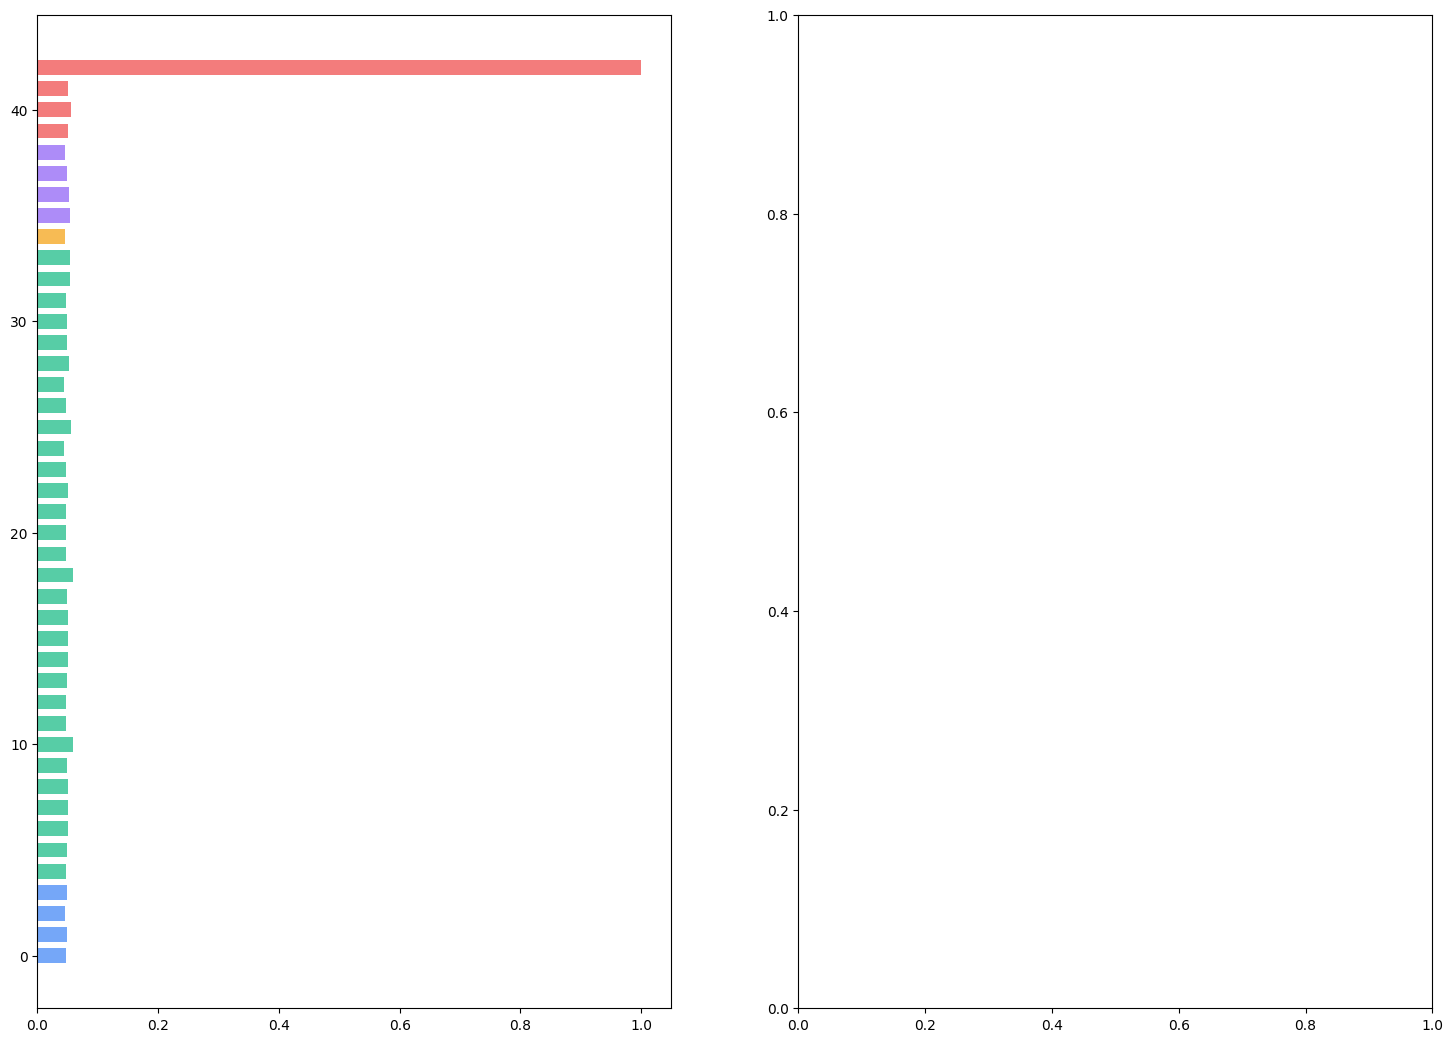

In [18]:
# ── Visualize: Part A (True Null FPR) + Part B (Variance-only detection) ──
fig, axes = plt.subplots(1, 2, figsize=(18, max(len(fp_df)*0.3, 6)))

colors = {'core': '#3b82f6', 'extended': '#10b981', 'dcov': '#f59e0b',
          'distribution': '#8b5cf6', 'MINE': '#ef4444'}

# --- Left: True Null FPR ---
ax = axes[0]
y_pos = range(len(fp_df))
bar_colors = [colors.get(g, '#666') for g in fp_df['group']]
ax.barh(y_pos, fp_df['fp_rate'], color=bar_colors, alpha=0.7, height=0.7)
ax.errorbar(fp_df['fp_rate'], y_pos,
            xerr=[fp_df['fp_rate']-fp_df['ci_lo'], fp_df['ci_hi']-fp_df['fp_rate']],
            fmt='none', color='black', capsize=2, lw=0.8)
ax.axvline(0.05, color='red', ls='--', lw=1.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(fp_df['metric'], fontsize=7)
ax.set_xlabel('FP rate')
ax.set_title(f'Part A: True Null FPR (n={n_null_cases})')
ax.invert_yaxis()

# --- Right: Variance-only detection ---
ax = axes[1]
det_sorted = det_df.reset_index(drop=True)
y_pos = range(len(det_sorted))
bar_colors = [colors.get(g, '#666') for g in det_sorted['group']]
ax.barh(y_pos, det_sorted['detection_rate'], color=bar_colors, alpha=0.7, height=0.7)
ax.errorbar(det_sorted['detection_rate'], y_pos,
            xerr=[det_sorted['detection_rate']-det_sorted['ci_lo'],
                  det_sorted['ci_hi']-det_sorted['detection_rate']],
            fmt='none', color='black', capsize=2, lw=0.8)
ax.axvline(0.05, color='red', ls='--', lw=1, alpha=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(det_sorted['metric'], fontsize=7)
ax.set_xlabel('Detection rate')
ax.set_title(f'Part B: Variance-Only Detection (n={n_var_cases})')
ax.invert_yaxis()

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, alpha=0.7, label=g)
                   for g, c in colors.items() if g in fp_df['group'].values]
axes[1].legend(handles=legend_elements, loc='lower right', fontsize=8)

plt.tight_layout()
fig.savefig(OUT_DIR / 'null_calibration_overview.png', bbox_inches='tight', dpi=150)
plt.show()

## 4. Null Baseline Values

For each metric, what's the typical observed value under True Null?
Metrics with high null baselines (like MIC ~0.16) have positive bias.

In [ ]:
print(f'Null baseline values (n={n_total} True Null cases):')
print(f'{"Metric":>25s}  {"Obs mean":>10s}  {"Obs std":>10s}  {"Group":>12s}')
print('-' * 65)

# Core
for mname in ['pearson', 'spearman', 'dcor', 'eta2']:
    vals = core_obs[mname]
    print(f'{mname:>25s}  {vals.mean():>10.4f}  {vals.std():>10.4f}  {"core":>12s}')

# Extended
for nm in EXT_METRICS:
    vals = ext_df[f'{nm}_obs']
    print(f'{nm:>25s}  {vals.mean():>10.4f}  {vals.std():>10.4f}  {"extended":>12s}')

# dcov
print(f'{"dcov":>25s}  {dcov_obs.mean():>10.4f}  {dcov_obs.std():>10.4f}  {"dcov":>12s}')

# Distribution
for nm in ['ew_dist_ks', 'ew_dist_wass', 'ec_dist_ks', 'ec_dist_wass']:
    vals = dist_df[f'{nm}_obs']
    print(f'{nm:>25s}  {vals.mean():>10.4f}  {vals.std():>10.4f}  {"distribution":>12s}')

# MINE
if RUN_MINE:
    for mname in mine_names:
        vals = mine_obs[mname]
        print(f'{mname:>25s}  {vals.mean():>10.4f}  {vals.std():>10.4f}  {"MINE":>12s}')

## 5. FP Rate by Generation Factor (True Null only)

Check if any metric's FP rate varies across x_distribution or noise_dist within the True Null subset.

In [ ]:
# Restrict to True Null for FPR factor analysis
pval_null = pval_all[pval_all['category'] == 'true_null'].copy()

for factor, levels in [('x_distribution', X_DISTRIBUTIONS),
                       ('noise_dist', NOISE_DISTRIBUTIONS)]:
    fp_by = []
    for nm in all_metric_names:
        rates = []
        for lv in levels:
            mask = pval_null[factor] == lv
            rates.append((pval_null.loc[mask, f'p_{nm}'] <= 0.05).mean())
        fp_by.append({'metric': nm, 'max_fp': max(rates), 'min_fp': min(rates),
                      'range': max(rates) - min(rates)})
    fp_var = pd.DataFrame(fp_by).sort_values('range', ascending=False)
    print(f'\n=== True Null FP variation across {factor} ===')
    print(fp_var.head(10).to_string(index=False))

# FP rate by noise_dist (core 4 + dcov)
print('\n\n=== True Null FP rate by noise_dist (core 4 + dcov) ===')
for mname in ['pearson', 'spearman', 'dcor', 'eta2', 'dcov']:
    rates = {}
    for nd in NOISE_DISTRIBUTIONS:
        m = pval_null['noise_dist'] == nd
        rates[nd] = (pval_null.loc[m, f'p_{mname}'] <= 0.05).mean()
    print(f'  {mname:>12s}:  ' + '  '.join(f'{nd}={r:.2%}' for nd, r in rates.items()))

## 6. Save Results

In [ ]:
# Save raw arrays for potential downstream use
np.savez_compressed(
    OUT_DIR / '_core_arrays.npz',
    **{f'{m}_obs': core_obs[m] for m in core_obs},
    **{f'{m}_null': core_null[m] for m in core_null},
    dcov_obs=dcov_obs, dcov_null=dcov_null,
)
if RUN_MINE:
    np.savez_compressed(
        OUT_DIR / '_mine_arrays.npz',
        **{f'{m}_obs': mine_obs[m] for m in mine_names},
        **{f'{m}_null': mine_null[m] for m in mine_names},
    )

# Save p-value table
pval_all.to_parquet(OUT_DIR / 'pvalues_all_metrics.parquet', index=False)

meta_df.to_csv(OUT_DIR / 'null_meta.csv', index=False)

print(f'Saved to {OUT_DIR}/')
for f in sorted(OUT_DIR.iterdir()):
    if not f.name.startswith('_mine_ckpt'):
        print(f'  {f.name} ({f.stat().st_size/1e6:.1f} MB)')

## 7. Summary

In [ ]:
print('='*60)
print('S4 NULL CALIBRATION + VARIANCE-ONLY SUMMARY')
print('='*60)
print(f'Total cases: {n_total}')
print(f'  True Null:      {n_null_cases} (constant spread, {N_PER_COMBO_NULL}/combo)')
print(f'  Variance-only:  {n_var_cases} (non-constant spread, {N_PER_COMBO_VAR}/combo)')
print(f'Metrics: {len(all_metric_names)}')
print()

# Part A summary
calibrated = fp_df[(fp_df['ci_lo'] <= 0.05) & (fp_df['ci_hi'] >= 0.05)]
high_fp = fp_df[fp_df['ci_lo'] > 0.05]
low_fp = fp_df[fp_df['ci_hi'] < 0.05]

print(f'── Part A: True Null FPR ──')
print(f'Calibrated (5% within CI): {len(calibrated)}/{len(fp_df)}')
if len(high_fp) > 0:
    print(f'Anti-conservative (FP > 5%):')
    for _, r in high_fp.iterrows():
        print(f'  {r["metric"]:>25s}  FP={r["fp_rate"]:.2%}')
if len(low_fp) > 0:
    print(f'Conservative (FP < 5%):')
    for _, r in low_fp.iterrows():
        print(f'  {r["metric"]:>25s}  FP={r["fp_rate"]:.2%}')

# Part B summary
print(f'\n── Part B: Variance-Only Detection ──')
det_high = det_df[det_df['detection_rate'] > 0.10].sort_values('detection_rate', ascending=False)
det_low  = det_df[det_df['detection_rate'] <= 0.10]
print(f'Detectable (>10%): {len(det_high)}/{len(det_df)}')
if len(det_high) > 0:
    for _, r in det_high.head(10).iterrows():
        print(f'  {r["metric"]:>25s}  det={r["detection_rate"]:.1%}')
print(f'Not detectable (≤10%): {len(det_low)}/{len(det_df)}')